In [ ]:
!pip install tensorflow-io
!apt-get install -y python3-opencv git
!rm -rf k

!git clone --branch single-branch https://github.com/Hussain-SZ/k-neural-api.git k
!cd k && pip install .

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
Suggested packages:
  python-numpy-doc python3-pytest
The following NEW packages will be installed:
  python3-numpy python3-opencv
0 upgraded, 2 newly installed, 0 to remove and 38 not upgraded.
Need to get 5,274 kB of archives.
After this operation, 27.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-opencv amd64 4.5.4+dfsg-9ubuntu4+jammy1 [1,807 kB]
Fetched 5,274 kB in 3s (1,600 kB/s)                                            
Selecting previously unselected package python3-numpy.
(Reading database ... 128663 files and directories currently installed.)
Preparing to unpack .../python3-numpy_1%3a1.21.5-1ubuntu22.04.1_amd64.deb ...
Unpack

# Dataset Preparation

In [ ]:
import os
import cv2
import numpy as np

def crop_images_from_csv(orig_data_dir, dest_data_dir, csv_file, include_original=False, verbose=False, prefix='img_'):
    with open(csv_file, "r") as myfile:
        csv_lines = myfile.readlines()

    a_lines = []
    for i, str_line in enumerate(csv_lines):
        if i == 0: 
            continue
        a_line = str_line.strip().split(',')
        a_lines.append(a_line)

    if not os.path.isdir(dest_data_dir):
        os.makedirs(dest_data_dir)

    last_image_file = ''
    original_count = 0
    failed_count = 0

    for line_count, a_line in enumerate(a_lines):
        class_name = a_line[3]
        dest_folder_name = os.path.join(dest_data_dir, class_name)
        dest_file_name = os.path.join(dest_folder_name, f"{prefix}{line_count}.jpg")
        orig_file_name = os.path.join(orig_data_dir, a_line[0])

        if not os.path.exists(orig_file_name):
            if verbose:
                print(f"File does not exist: {orig_file_name}")
            failed_count += 1
            continue

        if last_image_file != orig_file_name:
            img = cv2.imread(orig_file_name)
            last_image_file = orig_file_name
            original_count += 1
            if verbose:
                print(f"Original image shape: {img.shape}")
            if include_original:
                if not os.path.isdir(dest_folder_name):
                    os.makedirs(dest_folder_name)
                cv2.imwrite(os.path.join(dest_folder_name, f"ori_{prefix}{original_count}.jpg"), img)

        y1, x1, y2, x2 = map(int, a_line[4:8])
        x_min, x_max = min(x1, x2), max(x1, x2)
        y_min, y_max = min(y1, y2), max(y1, y2)

        crop_img = img[x_min:x_max, y_min:y_max]

        if crop_img.shape[0] == 0 or crop_img.shape[1] == 0:
            failed_count += 1
            if verbose:
                print("Failed cropping.")
        else:
            if not os.path.isdir(dest_folder_name):
                os.makedirs(dest_folder_name)
            cv2.imwrite(dest_file_name, crop_img)

    print("Done cropping.")
    print("Processed files:", line_count + 1, "Failed count:", failed_count, "Original images:", original_count)


!rm -rf up
!git clone https://github.com/joaopauloschuler/PlantDoc-Object-Detection-Dataset.git up

crop_images_from_csv(
    orig_data_dir='up/TRAIN',
    dest_data_dir='cropped_train/',
    csv_file='up/train_labels.csv',
    include_original=False,
    prefix='train_'
)

crop_images_from_csv(
    orig_data_dir='up/TEST',
    dest_data_dir='cropped_test/',
    csv_file='up/test_labels.csv',
    include_original=False,
    prefix='test_'
)

!mkdir -p cropped_all
!cp -r cropped_train/* cropped_all/
!cp -r cropped_test/* cropped_all/


Cloning into 'up'...
remote: Enumerating objects: 5190, done.
remote: Counting objects: 100% (1954/1954), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 5190 (delta 1924), reused 1814 (delta 1814), pack-reused 3236 (from 1)
Receiving objects: 100% (5190/5190), 941.87 MiB | 23.48 MiB/s, done.
Resolving deltas: 100% (2438/2438), done.
Updating files: 100% (5199/5199), done.
Done cropping.
Processed files: 8469 Failed count: 37 Original images: 2340
Done cropping.
Processed files: 452 Failed count: 1 Original images: 235


# Data Loading & Augmentation

In [ ]:
import cai.util
import cai.datasets

datagen = cai.util.create_image_generator(
    vertical_flip=True,
    horizontal_flip=True,
    rotation_range=90,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    fill_mode='nearest'
)

train_x, val_x, test_x, train_y, val_y, test_y, classweight, classes = cai.datasets.load_images_from_folders(
    seed=7,
    root_dir="cropped_all/",
    lab=False,
    verbose=True,
    bipolar=False,
    base_model_name='plant_doc',
    has_training=True,
    has_validation=True,
    has_testing=True,
    training_size=0.65,
    validation_size=0.15,
    test_size=0.2,
    target_size=(299, 299)
)

print(f"Number of classes: {len(classes)}")


2025-09-01 18:25:53.413593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756751153.594762      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756751153.648649      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading  29  classes.
loading train images
train shape is: (5761, 299, 299, 3)
loading validation images
validation shape is: (1333, 299, 299, 3)
loading test images
test shape is: (1789, 299, 299, 3)
Channel  0  min: 0.0  max: 1.0
Channel  1  min: 0.0  max: 1.0
Channel  2  min: 0.0  max: 1.0
Loaded.
Number of classes: 29


In [ ]:
import tensorflow as tf
from tensorflow import keras
import cai.models

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_util8EndsWithESt17basic_string_viewIcSt11char_traitsIcEES4_']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZN3tsl8str_util9LowercaseB5cxx11ESt17basic_s

In [5]:
import os, random, cv2, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Dropout, Reshape, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Architecture

In [ ]:


import os, random, cv2, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Dropout, Reshape, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


IMG_SIZE   = (299, 299)      
BATCH_SIZE = 32


num_classes = len(classes)
class_names = list(classes)
class_weight = {i: float(w) for i, w in enumerate(classweight)} 


train_ds = datagen.flow(train_x, train_y, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = ImageDataGenerator().flow(val_x,   val_y,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = ImageDataGenerator().flow(test_x,  test_y,  batch_size=BATCH_SIZE, shuffle=False)


def transformer_encoder(inputs, num_heads, ff_dim, dropout=0.1, name=None):
    x = LayerNormalization(epsilon=1e-6, name=None if not name else f"{name}_ln1")(inputs)
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=ff_dim,
        output_shape=inputs.shape[-1]
    )(x, x)
    x = Add(name=None if not name else f"{name}_res1")([attn, inputs])

    y = LayerNormalization(epsilon=1e-6, name=None if not name else f"{name}_ln2")(x)
    y = Dense(ff_dim, activation='relu', name=None if not name else f"{name}_ff1")(y)
    y = Dense(inputs.shape[-1], name=None if not name else f"{name}_ff2")(y)
    x = Add(name=None if not name else f"{name}_res2")([y, x])
    return x


def create_cnn_transformer_hybrid(input_shape=(299, 299, 3),
                                  num_classes=1000,
                                  num_heads=4, ff_dim=256, dropout=0.3):
    cnn_base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in cnn_base.layers:
        layer.trainable = False  

    inputs = Input(shape=input_shape, name="input_layer")
    x = cnn_base(inputs)                         

    
    patch_dim = x.shape[-1]                      
    seq_len   = x.shape[1] * x.shape[2]          
    x = Reshape((seq_len, patch_dim), name="reshape")(x)  

    
    x = transformer_encoder(x, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout, name="tx1")
    x = transformer_encoder(x, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout, name="tx2")

    
    x = GlobalAveragePooling1D(name="gap1d")(x)
    x = Dropout(dropout, name="head_do")(x)
    outputs = Dense(num_classes, activation='softmax', name='pred')(x)

    model = Model(inputs, outputs, name="CNN_Transformer_Hybrid")
    return model

model = create_cnn_transformer_hybrid(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes,
    num_heads=4, ff_dim=256, dropout=0.3
)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

I0000 00:00:1756751204.087839      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "CNN_Transformer_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 8, 8,      │ 21,802,784 │ input_layer[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 2048)  │          0 │ inception_v3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ln1             │ (None, 64, 2048)  │      4,096 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 2048)  │  8,393,728 │ tx1_ln1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ tx1_ln1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_res1 (Add)      │ (None, 64, 2048)  │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ln2             │ (None, 64, 2048)  │      4,096 │ tx1_res1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ff1 (Dense)     │ (None, 64, 256)   │    524,544 │ tx1_ln2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ff2 (Dense)     │ (None, 64, 2048)  │    526,336 │ tx1_ff1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_res2 (Add)      │ (None, 64, 2048)  │          0 │ tx1_ff2[0][0],    │
│                     │                   │            │ tx1_res1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ln1             │ (None, 64, 2048)  │      4,096 │ tx1_res2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 2048)  │  8,393,728 │ tx2_ln1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ tx2_ln1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_res1 (Add)      │ (None, 64, 2048)  │          0 │ multi_head_atten… │
│                     │                   │            │ tx1_res2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ln2             │ (None, 64, 2048)  │      4,096 │ tx2_res1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ff1 (Dense)     │ (None, 64, 256)   │    524,544 │ tx2_ln2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ff2 (Dense)     │ (None, 64, 2048)  │    526,336 │ tx2_ff1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_res2 (Add)      │ (None, 64, 2048)  │          0 │ tx2_ff2[0][0],    │
│                     │                   │            │ tx2_res1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap1d               │ (None, 2048)      │          0 │ tx2_res2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 40,767,805 (155.52 MB)

 Trainable params: 18,965,021 (72.35 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:

checkpoint_s1 = keras.callbacks.ModelCheckpoint(
    "best_stage1.keras", monitor="accuracy", mode="max", save_best_only=True, verbose=1
)
checkpoint_s2 = keras.callbacks.ModelCheckpoint(
    "best_stage2.keras", monitor="accuracy", mode="max", save_best_only=True, verbose=1
)
checkpoint_s3 = keras.callbacks.ModelCheckpoint(
    "best_stage3.keras", monitor="accuracy", mode="max", save_best_only=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="loss", factor=0.5, patience=8, min_lr=1e-6, verbose=1
)
early_stop = keras.callbacks.EarlyStopping(
    monitor="loss", patience=12, restore_best_weights=True, verbose=1
)

def merge_histories(hlist):
    out = {"loss": [], "accuracy": []}
    for h in hlist:
        out["loss"]     += h.history.get("loss", [])
        out["accuracy"] += h.history.get("accuracy", [])
    return out

_histories = []

# Training


In [ ]:
h1 = model.fit(
    train_ds,
    epochs=100,
    class_weight=class_weight,
    callbacks=[checkpoint_s1, reduce_lr, early_stop],
    verbose=1
)
_histories.append(h1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1756751229.310539     193 service.cc:148] XLA service 0x7bf868001f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756751229.311397     193 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1756751231.846279     193 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/181 ━━━━━━━━━━━━━━━━━━━━ 1:33:39 31s/step - accuracy: 0.0312 - loss: 62.8071

I0000 00:00:1756751243.086370     193 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.2554 - loss: 35.0237
Epoch 1: accuracy improved from -inf to 0.34109, saving model to best_stage1.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 143s 623ms/step - accuracy: 0.2559 - loss: 34.9930 - learning_rate: 1.0000e-04
Epoch 2/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.4585 - loss: 21.7487
Epoch 2: accuracy improved from 0.34109 to 0.46797, saving model to best_stage1.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 105s 577ms/step - accuracy: 0.4585 - loss: 21.7467 - learning_rate: 1.0000e-04
Epoch 3/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.5194 - loss: 19.0928
Epoch 3: accuracy improved from 0.46797 to 0.51154, saving model to best_stage1.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 104s 575ms/step - accuracy: 0.5194 - loss: 19.0928 - learning_rate: 1.0000e-04
Epoch 4/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.5375 - loss: 17.7948
Epoch 4: accuracy improved from 0.51154 to 0.55008, saving model to best_

In [9]:
model = keras.models.load_model("best_stage1.keras")
cnn = model.get_layer('inception_v3')
for lyr in cnn.layers:
    lyr.trainable = True

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

h2 = model.fit(
    train_ds,
    epochs=50, #50
    class_weight=class_weight,
    callbacks=[checkpoint_s2, reduce_lr, early_stop],
    verbose=1
)
_histories.append(h2)

Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.4325 - loss: 36.0116
Epoch 1: accuracy improved from -inf to 0.47943, saving model to best_stage2.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 235s 757ms/step - accuracy: 0.4327 - loss: 35.9752 - learning_rate: 1.0000e-05
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.5563 - loss: 19.9428
Epoch 2: accuracy improved from 0.47943 to 0.56865, saving model to best_stage2.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 113s 621ms/step - accuracy: 0.5563 - loss: 19.9395 - learning_rate: 1.0000e-05
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.6214 - loss: 15.7176
Epoch 3: accuracy improved from 0.56865 to 0.61968, saving model to best_stage2.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 111s 611ms/step - accuracy: 0.6214 - loss: 15.7160 - learning_rate: 1.0000e-05
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.6366 - loss: 13.7264
Epoch 4: accuracy improved from 0.61968 to 0.65162, saving model 

In [10]:
model = keras.models.load_model("best_stage2.keras")
cnn = model.get_layer('inception_v3')
for lyr in cnn.layers:
    lyr.trainable = True

model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-6),
              loss='categorical_crossentropy', metrics=['accuracy'])

h3 = model.fit(
    train_ds,
    epochs=50,  #1
    class_weight=class_weight,
    callbacks=[checkpoint_s3, reduce_lr, early_stop],
    verbose=1
)
_histories.append(h3)


Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.9233 - loss: 1.6877
Epoch 1: accuracy improved from -inf to 0.92484, saving model to best_stage3.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 223s 746ms/step - accuracy: 0.9233 - loss: 1.6872 - learning_rate: 5.0000e-06
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9216 - loss: 1.4171
Epoch 2: accuracy did not improve from 0.92484
181/181 ━━━━━━━━━━━━━━━━━━━━ 107s 591ms/step - accuracy: 0.9216 - loss: 1.4173 - learning_rate: 5.0000e-06
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.9233 - loss: 1.4764
Epoch 3: accuracy did not improve from 0.92484
181/181 ━━━━━━━━━━━━━━━━━━━━ 107s 589ms/step - accuracy: 0.9233 - loss: 1.4760 - learning_rate: 5.0000e-06
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9325 - loss: 1.2787
Epoch 4: accuracy improved from 0.92484 to 0.92623, saving model to best_stage3.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 109s 603ms/step - accuracy: 0.9324 


Evaluating on TEST split...
Test Loss: 1.3642, Test Acc: 0.7680

Classification report (TEST):
                                      precision    recall  f1-score   support

                     Apple Scab Leaf     0.0000    0.0000    0.0000        35
                          Apple leaf     0.7381    0.6200    0.6739        50
                     Apple rust leaf     0.7778    0.7778    0.7778        36
                    Bell_pepper leaf     0.8305    0.7538    0.7903        65
               Bell_pepper leaf spot     0.5660    0.5660    0.5660        53
                      Blueberry leaf     0.8478    0.9231    0.8839       169
                         Cherry leaf     0.7674    0.6875    0.7253        48
                 Corn Gray leaf spot     0.5000    0.3125    0.3846        16
                    Corn leaf blight     0.7765    0.8919    0.8302        74
                      Corn rust leaf     0.9167    0.8462    0.8800        26
                          Peach leaf     0.85

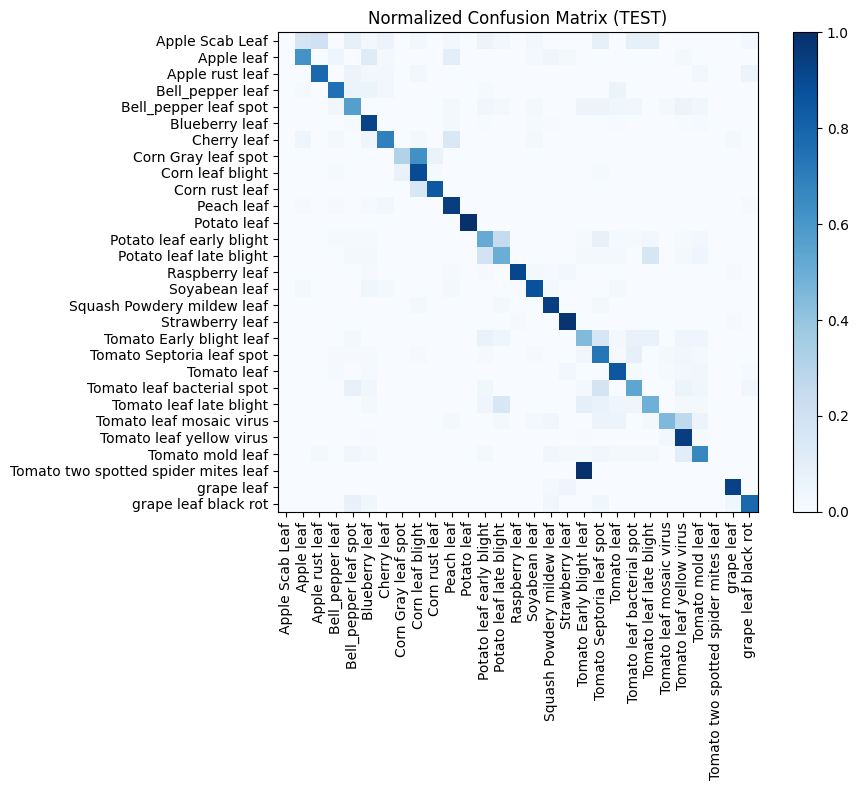

In [ ]:
print("\nEvaluating on TEST split...")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


probs = model.predict(test_x, batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = np.argmax(test_y, axis=1)

print("\nClassification report (TEST):")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)
plt.figure(figsize=(10,8))
plt.imshow(cm_norm, interpolation="nearest", cmap="Blues")
plt.title("Normalized Confusion Matrix (TEST)")
plt.colorbar()
ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.tight_layout(); plt.show()

# Test-Time Augmentation (TTA)

In [ ]:

def tta_predict_array(model, X, n=8, batch=BATCH_SIZE):
    preds = []
    for i in range(n):
        Xa = X.copy()
        if i % 2 == 1:
            Xa = Xa[:, :, ::-1, :]              
        if i % 4 == 2:
            Xa = np.rot90(Xa, k=1, axes=(1,2))  
        if i % 4 == 3:
            Xa = np.rot90(Xa, k=3, axes=(1,2))  
        preds.append(model.predict(Xa, batch_size=batch, verbose=0))
    return np.mean(preds, axis=0)

test_X = test_x.astype(np.float32)
test_y_idx = np.argmax(test_y, axis=1)

tta_probs = tta_predict_array(model, test_X, n=8, batch=BATCH_SIZE)
tta_pred  = np.argmax(tta_probs, axis=1)

print("\nTTA TEST Accuracy:", accuracy_score(test_y_idx, tta_pred))
print("\nClassification report (TTA on TEST):")
print(classification_report(test_y_idx, tta_pred, target_names=class_names, digits=4, zero_division=0))


TTA TEST Accuracy: 0.7931805477920626

Classification report (TTA on TEST):
                                      precision    recall  f1-score   support

                     Apple Scab Leaf     0.0000    0.0000    0.0000        35
                          Apple leaf     0.7500    0.6600    0.7021        50
                     Apple rust leaf     0.8056    0.8056    0.8056        36
                    Bell_pepper leaf     0.8947    0.7846    0.8361        65
               Bell_pepper leaf spot     0.5312    0.6415    0.5812        53
                      Blueberry leaf     0.8457    0.9408    0.8908       169
                         Cherry leaf     0.8462    0.6875    0.7586        48
                 Corn Gray leaf spot     0.4545    0.3125    0.3704        16
                    Corn leaf blight     0.8049    0.8919    0.8462        74
                      Corn rust leaf     0.8800    0.8462    0.8627        26
                          Peach leaf     0.8613    0.9516    0.9

# Gradcam

Grad-CAM target layer: mixed10
Wrapper approach failed: The name "input_layer" is used 2 times in the model. All operation names should be unique.
Falling back to simple approach
Layer mixed10 not found, using random heatmap
Layer mixed10 not found, using random heatmap
Layer mixed10 not found, using random heatmap
Layer mixed10 not found, using random heatmap
Layer mixed10 not found, using random heatmap


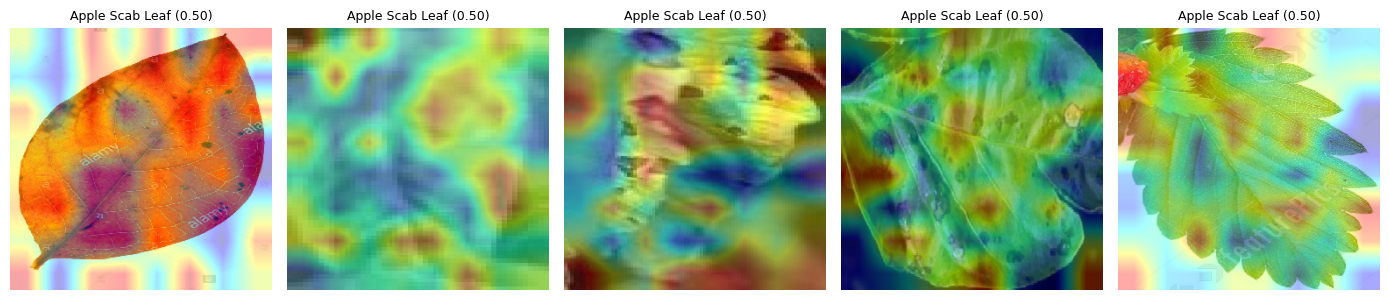

In [ ]:

def get_inception_block(model, preferred="mixed10"):
    inc = None
    for lyr in model.layers:
        if isinstance(lyr, keras.Model) and lyr.name.startswith("inception_v3"):
            inc = lyr; break
    if preferred in [l.name for l in inc.layers]:
        return inc, preferred
    
    for lyr in reversed(inc.layers):
        if "mixed" in lyr.name:
            return inc, lyr.name
    

def build_gradcam_wrapper(model, target_block_name):
    
    
    inc_model = None
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("inception_v3"):
            inc_model = layer
            break
    if inc_model is None:
        raise RuntimeError("InceptionV3 submodel not found")

    
    target_layer_output = inc_model.get_layer(target_block_name).output


    feature_extractor = keras.Model(
        inputs=model.input,
        outputs=target_layer_output,
        name="feature_extractor"
    )

    
    new_input = keras.Input(shape=model.input_shape[1:], dtype=tf.float32, name="gradcam_input")
    conv_features = feature_extractor(new_input)
    predictions   = model(new_input)
    wrapper = keras.Model(inputs=new_input, outputs=[conv_features, predictions], name="gradcam_wrapper")
    return wrapper

def make_gradcam_heatmap(img_array, wrapper_model, class_index=None):
    if not isinstance(img_array, tf.Tensor):
        img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
    img_array = tf.Variable(img_array, trainable=True)

    with tf.GradientTape() as tape:
        tape.watch(img_array)
        conv_outputs, predictions = wrapper_model(img_array, training=False)
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))
        target_score = predictions[0, class_index]

    gradients = tape.gradient(target_score, conv_outputs)
    if gradients is None:
        print("Warning: Gradients are None. Using alternative method.")
        return np.random.random((8, 8)), int(class_index), float(target_score.numpy())

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]  # (H,W,C)
    heatmap = tf.reduce_sum(tf.multiply(pooled_gradients, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_heat = tf.reduce_max(heatmap)
    if max_heat > 0:
        heatmap = heatmap / max_heat
    return heatmap.numpy(), int(class_index), float(target_score.numpy())

def overlay_heatmap_on_image(orig_rgb, heatmap, alpha=0.35):
    h, w = orig_rgb.shape[:2]
    hm = cv2.resize(heatmap, (w, h), interpolation=cv2.INTER_LINEAR)
    hm_u8 = np.uint8(255 * hm)
    hm_col = cv2.applyColorMap(hm_u8, cv2.COLORMAP_JET)
    out_bgr = cv2.addWeighted(hm_col, alpha, cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR), 1 - alpha, 0)
    return cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)

def simple_gradcam_heatmap(img_array, model, class_index=None, layer_name="mixed10"):
    
    inc_model = None
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("inception_v3"):
            inc_model = layer
            break
    if inc_model is None:
        print("InceptionV3 submodel not found, using random heatmap")
        return np.random.random((8, 8)), 0, 0.5

    
    try:
        target_layer = inc_model.get_layer(layer_name)
        grad_model = keras.Model(inputs=model.input, outputs=[target_layer.output, model.output])
    except:
        print(f"Layer {layer_name} not found, using random heatmap")
        return np.random.random((8, 8)), 0, 0.5

    if not isinstance(img_array, tf.Tensor):
        img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_array)
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))
        target_score = predictions[0][class_index]

    grads = tape.gradient(target_score, conv_outputs)
    if grads is None:
        print("Gradients are None, using random heatmap")
        return np.random.random((8, 8)), int(class_index), float(target_score.numpy())

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_heat = tf.reduce_max(heatmap)
    if max_heat > 0:
        heatmap = heatmap / max_heat
    return heatmap.numpy(), int(class_index), float(target_score.numpy())


try:
    inc_submodel, target_block = get_inception_block(model, preferred="mixed10")
    print("Grad-CAM target layer:", target_block)
    gc_wrapper = build_gradcam_wrapper(model, target_block)
    use_wrapper = True
    print("Using wrapper approach")
except Exception as e:
    print(f"Wrapper approach failed: {e}")
    print("Falling back to simple approach")
    use_wrapper = False


TEST_DIR = "cropped_test" if os.path.isdir("cropped_test") else "cropped_all"

test_paths = []
for cls in os.listdir(TEST_DIR):
    cdir = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cdir):
        for f in os.listdir(cdir):
            if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp")):
                test_paths.append(os.path.join(cdir, f))

if len(test_paths) >= 5:
    random.seed(42)
    picks = random.sample(test_paths, 5)

    plt.figure(figsize=(14, 6))
    for i, path in enumerate(picks):
        img = keras.utils.load_img(path, target_size=IMG_SIZE)
        arr = keras.utils.img_to_array(img).astype("float32")
        x = arr[None, ...]  # (1, H, W, 3)

        try:
            if use_wrapper:
                heat, cls_idx, conf = make_gradcam_heatmap(x, gc_wrapper)
            else:
                heat, cls_idx, conf = simple_gradcam_heatmap(x, model)

            overlay = overlay_heatmap_on_image(np.uint8(np.clip(arr, 0, 255)), heat, alpha=0.35)

            plt.subplot(1, 5, i + 1)
            plt.imshow(overlay)
            title = class_names[cls_idx] if 0 <= cls_idx < len(class_names) else str(cls_idx)
            plt.title(f"{title} ({conf:.2f})", fontsize=9)
            plt.axis("off")
        except Exception as e:
            print(f"Error processing image {i+1}: {e}")
            plt.subplot(1, 5, i + 1)
            plt.imshow(np.uint8(np.clip(arr, 0, 255)))
            plt.title(f"Error: {str(e)[:20]}...", fontsize=9)
            plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough TEST images for Grad-CAM preview.")